# Agriculture Crop Production Prediction in India

This notebook analyzes agricultural data from India (2001-2014) to predict crop yields. We will:
1.  Load and clean multiple datasets (Production, Cost, Varieties).
2.  Merge them into a unified dataset.
3.  Perform Exploratory Data Analysis (EDA).
4.  Train a Machine Learning model (Random Forest) to predict crop yield.
5.  Evaluate the model's performance.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

## 2. Data Loading and Cleaning

We integrate data from three sources:
-   **`datafile (1).csv`**: Contains State-wise Cost of Cultivation and Yield data.
-   **`datafile (2).csv`**: Contains National-level Production, Area, and Yield time-series. We reshape this from wide format (years as columns) to long format.
-   **`datafile (3).csv`**: Contains details about Crop Varieties and Recommended Zones.

We also define helper functions to standardize column names and crop names (e.g., converting 'Paddy' to 'rice' so datasets match).

In [2]:
# Helper Functions
def clean_column_names(df):
    df.columns = df.columns.str.strip().str.replace(r'\s+', '_', regex=True).str.lower()
    return df

def clean_crop_name(name):
    if pd.isna(name): return name
    name = str(name).lower().strip()
    # Normalize common crop names
    if 'paddy' in name: return 'rice'
    if 'arhar' in name: return 'tur' # Arhar is Tur
    if 'gram' in name: return 'gram'
    if 'groundnut' in name: return 'groundnut'
    if 'maize' in name: return 'maize'
    return name

# Load Data
print("Loading datasets...")
df1 = pd.read_csv("datafile (1).csv") # State/Cost
df2 = pd.read_csv("datafile (2).csv") # Production Time Series
df3 = pd.read_csv("datafile (3).csv") # Varieties

# --- Process datafile (2): Production Time Series ---
print("Processing Production data...")
df2 = df2.rename(columns={df2.columns[0]: 'crop'})
id_vars = ['crop']
df2_long = pd.DataFrame()
metrics = ['Production', 'Area', 'Yield']

for metric in metrics:
    # Filter columns for this metric
    cols = [c for c in df2.columns if metric in c and 'crop' not in c]
    # Melt from wide to long
    temp = df2.melt(id_vars=['crop'], value_vars=cols, var_name='Year_Raw', value_name=metric)
    # Extract Year from string (e.g., "Production 2006-07" -> "2006-07")
    temp['Year'] = temp['Year_Raw'].apply(lambda x: re.search(r'\d{4}-\d{2}', x).group(0) if re.search(r'\d{4}-\d{2}', x) else None)
    temp = temp.drop(columns=['Year_Raw'])
    
    if df2_long.empty:
        df2_long = temp
    else:
        df2_long = pd.merge(df2_long, temp, on=['crop', 'Year'], how='outer')

df2_long['crop'] = df2_long['crop'].apply(clean_crop_name)

# --- Process datafile (1): State Costs ---
print("Processing Cost data...")
df1 = clean_column_names(df1)
df1 = df1.rename(columns={
    'cost_of_cultivation_(`/hectare)_a2+fl': 'cost_a2_fl',
    'cost_of_cultivation_(`/hectare)_c2': 'cost_c2',
    'cost_of_production_(`/quintal)_c2': 'cost_production_c2',
    'yield_(quintal/_hectare)_': 'yield_state'
})
df1['crop'] = df1['crop'].apply(clean_crop_name)

# --- Process datafile (3): Varieties ---
print("Processing Variety data...")
df3 = clean_column_names(df3)
rows = []
for idx, row in df3.iterrows():
    if pd.notna(row['recommended_zone']):
        # Clean zone string and split states
        zone_str = re.sub(r'under\s+.*', '', row['recommended_zone'], flags=re.IGNORECASE)
        zone_str = zone_str.replace(' and ', ',')
        states = [s.strip() for s in zone_str.split(',') if s.strip()]
        for state in states:
            new_row = row.to_dict()
            new_row['state'] = state
            rows.append(new_row)
df3_exploded = pd.DataFrame(rows)
if not df3_exploded.empty:
    df3_exploded = df3_exploded.drop(columns=['recommended_zone', 'unnamed:_4'])
    df3_exploded['crop'] = df3_exploded['crop'].apply(clean_crop_name)
    df3_exploded['state'] = df3_exploded['state'].str.strip()

# --- Merge Dataframes ---
print("Merging datasets...")
# Merge 1 & 2 on Crop
merged_df = pd.merge(df2_long, df1, on='crop', how='inner')

# Merge with 3 on Crop and State
if not df3_exploded.empty:
    final_df = pd.merge(merged_df, df3_exploded, on=['crop', 'state'], how='left')
else:
    final_df = merged_df

print(f"Final Merged Data Shape: {final_df.shape}")
final_df.head()

Loading datasets...
Processing Production data...
Processing Cost data...
Processing Variety data...
Merging datasets...
Final Merged Data Shape: (220, 12)


,crop,Production,Year,Area,Yield,state,cost_a2_fl,cost_c2,cost_production_c2,yield_(quintal/_hectare),variety,season/_duration_in_days
0,tur,97.0,2006-07,99.7,97.3,Uttar Pradesh,9794.05,23076.74,1941.55,9.83,NaN,NaN
1,tur,97.0,2006-07,99.7,97.3,Karnataka,10593.15,16528.68,2172.46,7.47,NaN,NaN
2,tur,97.0,2006-07,99.7,97.3,Gujarat,13468.82,19551.90,1898.30,9.59,NaN,NaN
3,tur,97.0,2006-07,99.7,97.3,Andhra Pradesh,17051.66,24171.65,3670.54,6.42,NaN,NaN
4,tur,97.0,2006-07,99.7,97.3,Maharashtra,17130.55,25270.26,2775.80,8.72,NaN,NaN


## 3. Exploratory Data Analysis (EDA)

We investigate the dataset to find missing values, outliers, and correlations.
Key focus: Relationship between **Cost of Production** and **Yield**.

,Production,Area,Yield,cost_a2_fl,cost_c2,cost_production_c2,yield_(quintal/_hectare)
count,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000
mean,175.320000,140.982273,122.743636,21883.892045,33319.438409,1211.395682,113.370909
std,48.561312,24.008865,18.635597,13000.545088,19272.394439,923.071701,253.075067
min,94.900000,94.500000,92.800000,8552.690000,12610.850000,85.790000,4.710000
25%,135.200000,121.925000,106.675000,13792.850000,20951.717500,680.150000,11.710000
50%,176.150000,139.550000,121.700000,17478.050000,27453.295000,789.900000,32.420000
75%,207.900000,163.400000,125.475000,24731.060000,35423.480000,1886.585000,40.542500
max,286.000000,175.100000,169.100000,66335.060000,91442.630000,3670.540000,1015.450000



Missing Values:
crop                          0
Production                    0
Year                          0
Area                          0
Yield                         0
state                         0
cost_a2_fl                    0
cost_c2                       0
cost_production_c2            0
yield_(quintal/_hectare)      0
variety                      85
season/_duration_in_days    105
dtype: int64


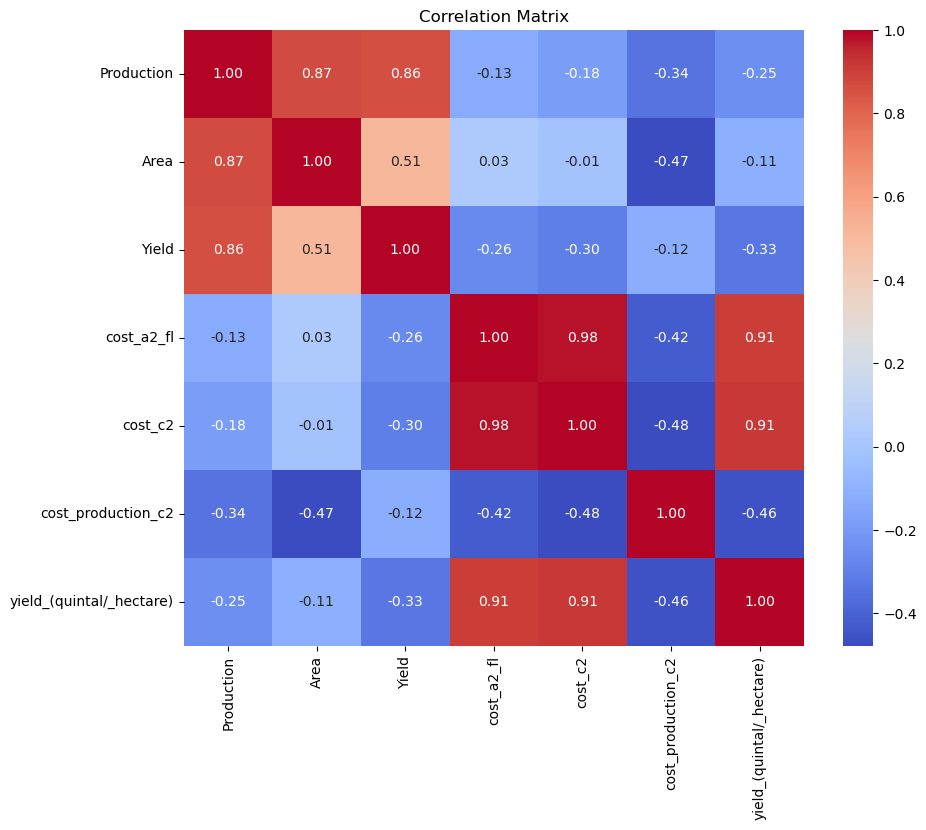


Correlation with State Yield:
yield_(quintal/_hectare)    1.000000
cost_c2                     0.914778
cost_a2_fl                  0.906959
Area                       -0.106332
Production                 -0.246239
Yield                      -0.328967
cost_production_c2         -0.457694
Name: yield_(quintal/_hectare), dtype: float64


In [3]:
# Summary Statistics
display(final_df.describe())

# Check Missing Values
print("\nMissing Values:")
print(final_df.isnull().sum())

# Correlation Analysis
numeric_cols = final_df.select_dtypes(include=[np.number]).columns
corr = final_df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

print("\nCorrelation with State Yield:")
if 'yield_(quintal/_hectare)' in corr.columns:
    print(corr['yield_(quintal/_hectare)'].sort_values(ascending=False))

## 4. Model Training

We will predict `yield_(quintal/_hectare)` using the following features:
-   **Numerical**: `cost_a2_fl`, `cost_c2`, `cost_production_c2`, `Year`.
-   **Categorical**: `state`, `crop`.

We use a **Random Forest Regressor** because it handles non-linear relationships well (important since crops like Sugarcane have vastly different yield scales compared to grains).

In [4]:
# Define Features and Target
feature_cols = ['cost_a2_fl', 'cost_c2', 'cost_production_c2', 'Year', 'state', 'crop']
target_col = 'yield_(quintal/_hectare)'

X = final_df[feature_cols].copy()
y = final_df[target_col]

# Clean Year (Convert '2006-07' to integer 2006)
X['Year'] = X['Year'].astype(str).str.split('-').str[0].astype(int)

# Preprocessing Pipeline
categorical_features = ['state', 'crop']
numerical_features = ['cost_a2_fl', 'cost_c2', 'cost_production_c2', 'Year']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and Train Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', model)])

print("Training model...")
pipeline.fit(X_train, y_train)
print("Model trained.")

Training model...
Model trained.


## 5. Evaluation

We evaluate the model using:
-   **R2 Score**: Explains variance (1.0 is perfect).
-   **MAE (Mean Absolute Error)**: Average error in quintals/hectare.

Model Performance:
MAE: 2.09 Quintal/Hectare
R2 Score: 0.9990


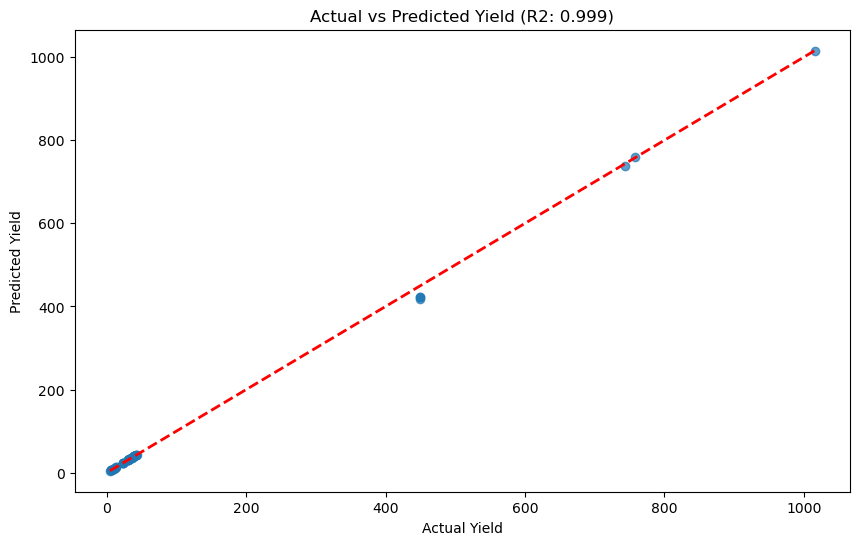

In [5]:
# Predictions
y_pred = pipeline.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:")
print(f"MAE: {mae:.2f} Quintal/Hectare")
print(f"R2 Score: {r2:.4f}")

# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title(f"Actual vs Predicted Yield (R2: {r2:.3f})")
plt.show()